In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Tắt các cảnh báo không cần thiết
import warnings
warnings.filterwarnings('ignore')

In [ ]:
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'

def load_data(file_path):
    df = pd.read_csv(file_path)
    return df

df = load_data(url)
display(df.head(10))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


Thống kê số lượng dữ liệu thiếu:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


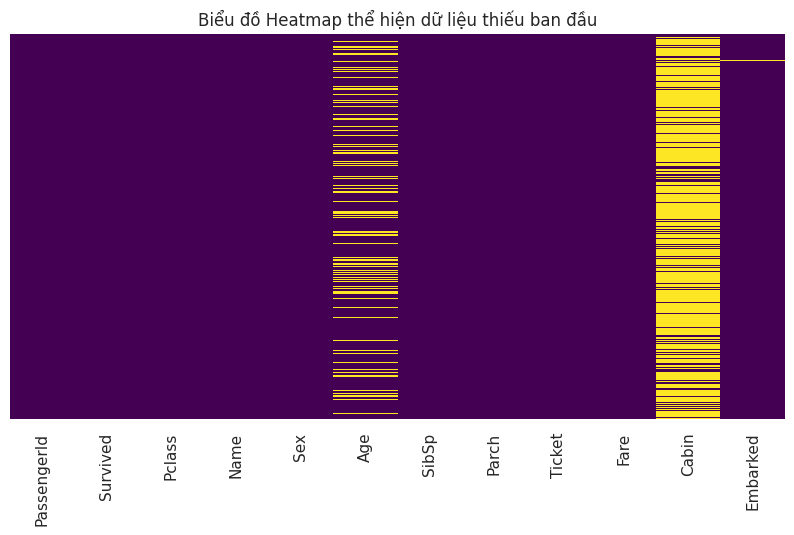

In [ ]:
print("Thống kê số lượng dữ liệu thiếu:")
print(df.isnull().sum())

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Biểu đồ Heatmap thể hiện dữ liệu thiếu ban đầu')
plt.show()

In [ ]:
# Tách cột Name thành firstName và secondName
df[['firstName', 'secondName']] = df['Name'].str.split(',', expand=True)

# Xóa cột Name
df.drop('Name', axis=1, inplace=True)
display(df[['firstName', 'secondName']].head(3))

,firstName,secondName
0,Braund,Mr. Owen Harris
1,Cumings,Mrs. John Bradley (Florence Briggs Thayer)
2,Heikkinen,Miss. Laina


In [ ]:
df['Sex'] = df['Sex'].replace({'male': 'M', 'female': 'F'})
print(df['Sex'].value_counts())

Sex
M    577
F    314
Name: count, dtype: int64


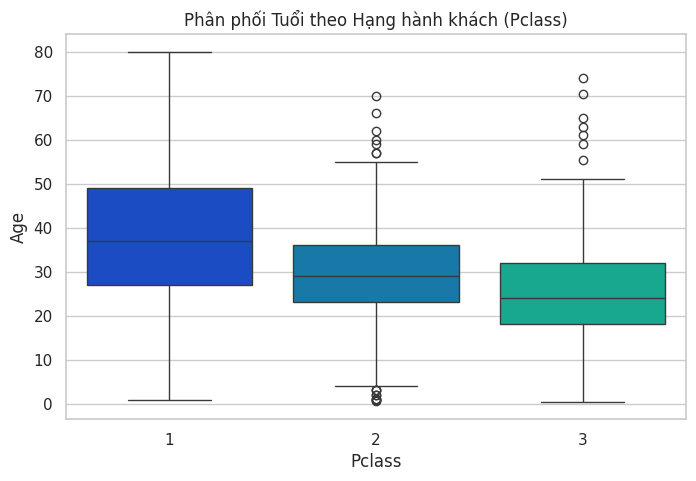

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Pclass', y='Age', data=df, palette='winter')
plt.title('Phân phối Tuổi theo Hạng hành khách (Pclass)')
plt.show()

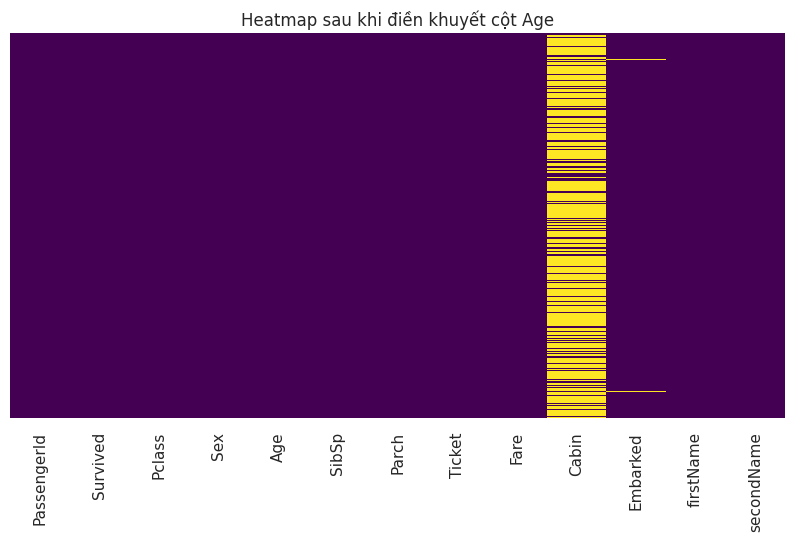

In [ ]:
# Tính tuổi trung bình theo Pclass
age_means = df.groupby('Pclass')['Age'].mean()

def impute_age(row):
    if pd.isnull(row['Age']):
        return age_means[row['Pclass']]
    else:
        return row['Age']

# Điền dữ liệu thiếu
df['Age'] = df.apply(impute_age, axis=1)

# Kiểm tra lại bằng Heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Heatmap sau khi điền khuyết cột Age')
plt.show()

In [ ]:
bins = [0, 12, 18, 60, 120]
labels = ['Kid', 'Teen', 'Adult', 'Older']
df['Agegroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
print(df['Agegroup'].value_counts())

Agegroup
Adult    730
Teen      70
Kid       69
Older     22
Name: count, dtype: int64


In [ ]:
df['namePrefix'] = df['secondName'].str.extract(' ([A-Za-z]+)\.', expand=False)
print(df['namePrefix'].value_counts().head(5))

namePrefix
Mr        517
Miss      182
Mrs       125
Master     40
Dr          7
Name: count, dtype: int64


In [ ]:
# Tạo familySize
df['familySize'] = 1 + df['SibSp'] + df['Parch']

# Tạo Alone (1 nếu familySize == 1, ngược lại 0)
df['Alone'] = df['familySize'].apply(lambda x: 1 if x == 1 else 0)

display(df[['SibSp', 'Parch', 'familySize', 'Alone']].head(5))

,SibSp,Parch,familySize,Alone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


In [ ]:
df['Cabin'] = df['Cabin'].fillna('Unknown')
df['typeCabin'] = df['Cabin'].astype(str).str[0]
df['typeCabin'] = df['typeCabin'].replace('U', 'Unknown')

print(df['typeCabin'].value_counts())

typeCabin
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64


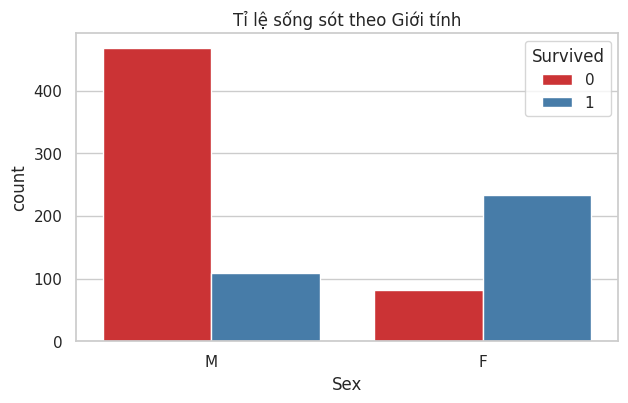

In [ ]:
plt.figure(figsize=(7, 4))
sns.countplot(x='Sex', hue='Survived', data=df, palette='Set1')
plt.title('Tỉ lệ sống sót theo Giới tính')
plt.show()

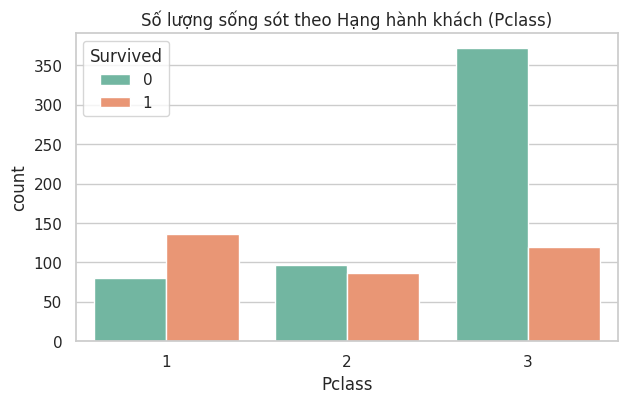

In [ ]:
plt.figure(figsize=(7, 4))
sns.countplot(x='Pclass', hue='Survived', data=df, palette='Set2')
plt.title('Số lượng sống sót theo Hạng hành khách (Pclass)')
plt.show()

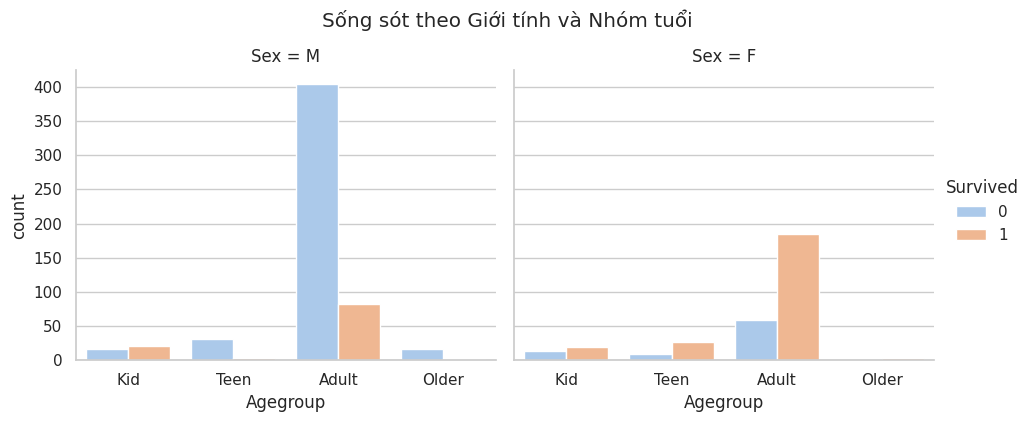

In [ ]:
sns.catplot(x='Agegroup', hue='Survived', col='Sex', data=df, kind='count', palette='pastel', height=4, aspect=1.2)
plt.suptitle('Sống sót theo Giới tính và Nhóm tuổi', y=1.05)
plt.show()

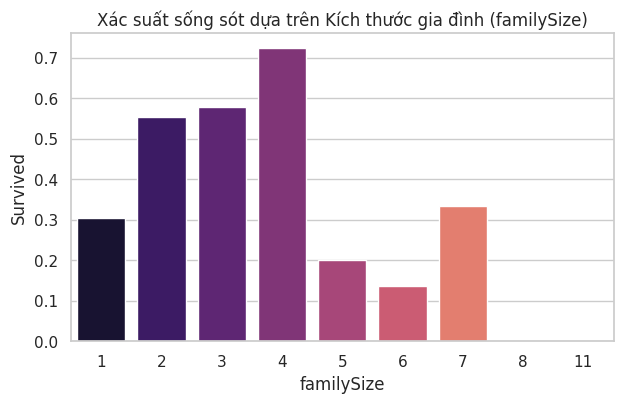

In [ ]:
plt.figure(figsize=(7, 4))
sns.barplot(x='familySize', y='Survived', data=df, errorbar=None, palette='magma')
plt.title('Xác suất sống sót dựa trên Kích thước gia đình (familySize)')
plt.show()

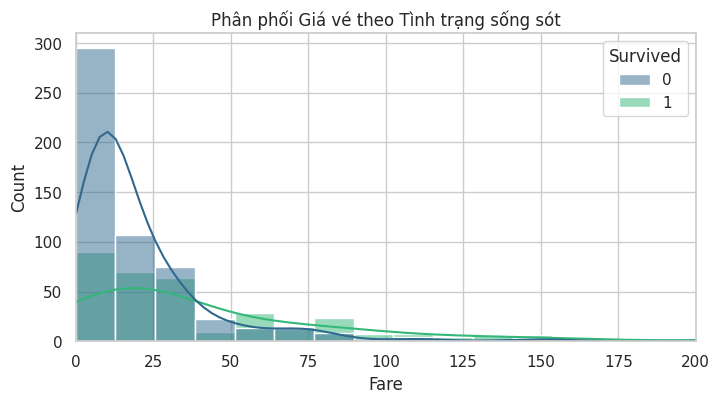

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Fare', hue='Survived', kde=True, bins=40, palette='viridis')
plt.title('Phân phối Giá vé theo Tình trạng sống sót')
plt.xlim(0, 200)
plt.show()

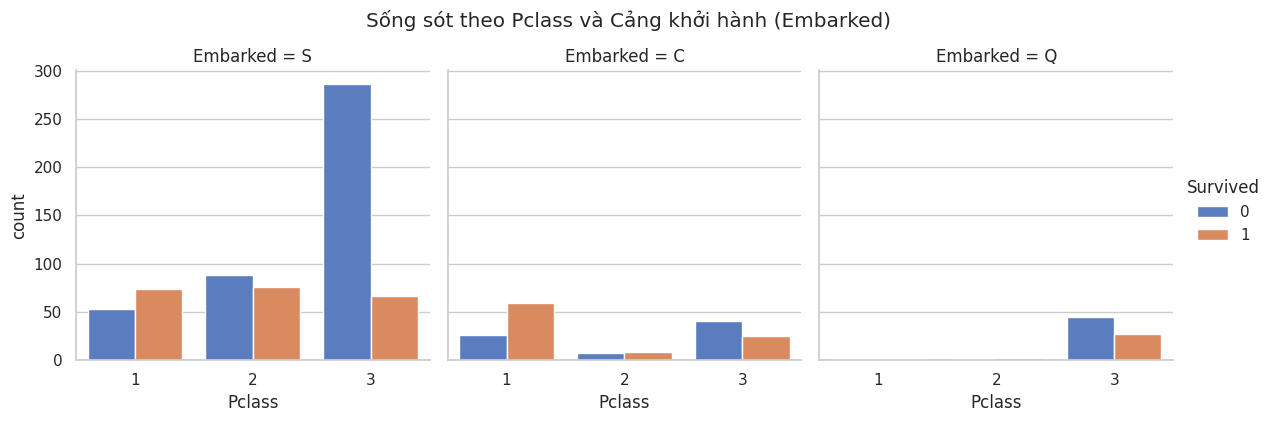

In [ ]:
sns.catplot(x='Pclass', hue='Survived', col='Embarked', data=df, kind='count', palette='muted', height=4, aspect=1)
plt.suptitle('Sống sót theo Pclass và Cảng khởi hành (Embarked)', y=1.05)
plt.show()